In [4]:
!pip install pandas pyarrow matplotlib seaborn jupyter



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\anfep\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
pip install seaborn

     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     -------------------------------------- 294.9/294.9 kB 9.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)

df = pd.read_parquet("../data/Reto_data_20251023_122206.parquet")

df.head()

,id,attachments,author,authorCategory,authorCategoryId,authorId,authorURL,automateProjectId,caption,context,contextTitle,country,createdAt,description,engagementRate,facebookAdAccountId,facebookIds,facebookMessengerThreadId,facebookPageId,group,hasImageOrVideo,host,ignored,image,influenceScore,...,metadata,minRating,parentCreatedAt,parentId,parentText,places,preciseId,private,rating,recipients,sentiment,sex,socialType,sourceData,sourceId,sourceLimitations,sourceName,sourceURL,tags,text,threadId,title,type,url,youtubeChannelId
0,c6adb4630994bdee807d387382d526bc,[],Consulta Popular,,,,,,,El camino hacia la consulta popular en Colombia,,co,1750834500000,,,,[],,,portal,False,www.proclamadelpacifico.com,False,,1,...,,,,,,[],es_1750834500000_c6adb4630994bdee807d387382d526bc,False,,[],UNKNOWN,u,,,,[],,https://www.proclamadelpacifico.com/el-camino-...,[],Hasta 1990 el C&oacute;digo Sustantivo del Tra...,c6f5b8840e9675c607bc42a16543c1d72ef4f771759834...,El camino hacia la consulta popular en Colombia,ar,https://www.proclamadelpacifico.com/el-camino-...,
1,9fee3686bd7f2fd45d381a9b388dfb5e,[],Consulta Popular,,,,,,,La Consulta popular constituyente,,co,1750836300000,,,,[],,,portal,False,www.proclamadelpacifico.com,False,,1,...,,,,,,[],es_1750836300000_9fee3686bd7f2fd45d381a9b388dfb5e,False,,[],UNKNOWN,u,,,,[],,https://www.proclamadelpacifico.com/la-consult...,[],La Consulta popular constituyente/El deliberad...,f565efdfc7bd00275467b1e2d8e90036f986e5e50d1896...,La Consulta popular constituyente,ar,https://www.proclamadelpacifico.com/la-consult...,
2,9adb9324d96a398905767afcf428e956,[],Daniel Hernandez,,,,,,,"Empleo juvenil, frente del mercado laboral que...",,co,1750837740000,,,,[],,,portal,False,www.portafolio.co,False,,4,...,,,,,,[],es-co_1750837740000_9adb9324d96a398905767afcf4...,False,,[],UNKNOWN,m,,,,[],,https://www.portafolio.co/economia/empleo/refo...,[],En medio de la expectativa por lo que vendr&aa...,3d97a4b17c73e05726d2a10e10edf6a653cfa03053e7ca...,"Empleo juvenil, frente del mercado laboral que...",ar,https://www.portafolio.co/economia/empleo/refo...,
3,be6ed61346de9fc96e3e797d70d275a9,[],,,,,,,,Petro da marcha atrás con consulta sobre <q>re...,,mx,1750840406000,,,,[],,,portal,False,www.eleconomista.com.mx,False,,4,...,,,,,,[],es-mx_1750840406000_be6ed61346de9fc96e3e797d70...,False,,[],UNKNOWN,u,,,,[],,https://www.eleconomista.com.mx/internacionale...,[],El Senado tampoco autoriz&oacute; a mediados d...,1e19407566ce89c0a86e50c86633f8ccf07ccfdb9e60c2...,Petro da marcha atr&aacute;s con consulta sobr...,ar,https://www.eleconomista.com.mx/internacionale...,
4,4a893f2667aa8eddb4c84fcd09fcd43f,[],,,,,,,,Petro firmó decreto de la <q>reforma</q> <q>la...,,co,1750848960000,,,,[],,,portal,False,www.kienyke.com,False,,3,...,,,,,,[],es_1750848960000_4a893f2667aa8eddb4c84fcd09fcd43f,False,,[],UNKNOWN,u,,,,[],,https://www.kienyke.com/politica/gustavo-petro...,[],Cr&eacute;ditos: X @infopresidencia El preside...,f689aa9604212e6e350dbfb942bc3579f07871b5f8b547...,Petro firm&oacute; decreto de la <q>reforma</q...,ar,https://www.kienyke.com/politica/gustavo-petro...,


In [11]:
df.shape
df.columns 
df.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4795 entries, 0 to 4794
Data columns (total 72 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   id                            4795 non-null   object
 1   attachments                   4795 non-null   object
 2   author                        4795 non-null   object
 3   authorCategory                4795 non-null   object
 4   authorCategoryId              4795 non-null   object
 5   authorId                      4795 non-null   object
 6   authorURL                     4795 non-null   object
 7   automateProjectId             4795 non-null   object
 8   caption                       4795 non-null   object
 9   context                       4795 non-null   object
 10  contextTitle                  4795 non-null   object
 11  country                       4795 non-null   object
 12  createdAt                     4795 non-null   object
 13  description       

# Columnas relevantes

## Para métricas
id, author - authorId, text, liked, engagementRate, title, sourceName, host

## Para sentimientos
text, language, author, createdAt

## Para propagación

threadId, parentId, parentCreatedAt, parentText

In [12]:
cols_interes = [
    "id", "threadId", "parentId", "parentText", "parentCreatedAt",
    "author", "authorId", "authorCategory", "createdAt",
    "text", "title", "language", "country",
    "liked", "engagementRate", "isComment", "isRetweet",
    "sourceName", "url"
]

df_small = df[cols_interes].copy()

df_small.head()


,id,threadId,parentId,parentText,parentCreatedAt,author,authorId,authorCategory,createdAt,text,title,language,country,liked,engagementRate,isComment,isRetweet,sourceName,url
0,c6adb4630994bdee807d387382d526bc,c6f5b8840e9675c607bc42a16543c1d72ef4f771759834...,,,,Consulta Popular,,,1750834500000,Hasta 1990 el C&oacute;digo Sustantivo del Tra...,El camino hacia la consulta popular en Colombia,es,co,[],,False,False,,https://www.proclamadelpacifico.com/el-camino-...
1,9fee3686bd7f2fd45d381a9b388dfb5e,f565efdfc7bd00275467b1e2d8e90036f986e5e50d1896...,,,,Consulta Popular,,,1750836300000,La Consulta popular constituyente/El deliberad...,La Consulta popular constituyente,es,co,[],,False,False,,https://www.proclamadelpacifico.com/la-consult...
2,9adb9324d96a398905767afcf428e956,3d97a4b17c73e05726d2a10e10edf6a653cfa03053e7ca...,,,,Daniel Hernandez,,,1750837740000,En medio de la expectativa por lo que vendr&aa...,"Empleo juvenil, frente del mercado laboral que...",es-co,co,[],,False,False,,https://www.portafolio.co/economia/empleo/refo...
3,be6ed61346de9fc96e3e797d70d275a9,1e19407566ce89c0a86e50c86633f8ccf07ccfdb9e60c2...,,,,,,,1750840406000,El Senado tampoco autoriz&oacute; a mediados d...,Petro da marcha atr&aacute;s con consulta sobr...,es-mx,mx,[],,False,False,,https://www.eleconomista.com.mx/internacionale...
4,4a893f2667aa8eddb4c84fcd09fcd43f,f689aa9604212e6e350dbfb942bc3579f07871b5f8b547...,,,,,,,1750848960000,Cr&eacute;ditos: X @infopresidencia El preside...,Petro firm&oacute; decreto de la <q>reforma</q...,es,co,[],,False,False,,https://www.kienyke.com/politica/gustavo-petro...


## Arreglar fechas

In [13]:
df_small["createdAt"] = pd.to_datetime(df_small["createdAt"], errors="coerce")
df_small["parentCreatedAt"] = pd.to_datetime(df_small["parentCreatedAt"], errors="coerce")


C:\Users\anfep\AppData\Local\Temp\ipykernel_65636\83462032.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_small["createdAt"] = pd.to_datetime(df_small["createdAt"], errors="coerce")
C:\Users\anfep\AppData\Local\Temp\ipykernel_65636\83462032.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_small["parentCreatedAt"] = pd.to_datetime(df_small["parentCreatedAt"], errors="coerce")


In [14]:
df_small[["createdAt", "parentCreatedAt"]].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4795 entries, 0 to 4794
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   createdAt        0 non-null      datetime64[ns]
 1   parentCreatedAt  0 non-null      datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 75.0 KB


# EDA para Propagación

## ¿Cuántos mensajes son raíz vs respuestas?

In [ ]:
df_small["is_root"] = df_small["parentId"].replace("", None).isna()

df_small["is_root"].value_counts()

is_root
False    4567
True      228
Name: count, dtype: int64

Como solo 228 mensajes son raíz (es decir, tienen parentId vacío, esto lleva a que sean primeros posts, videos, publicaciones originales)

Y con 4567 son respuestas o comentarios compartidos. 

Así que podemos decir que hay conversaciones activas y profundas, no solo posts sueltos.

### ¿Cuántos mensajes tiene cada threadId?

In [16]:
tam_hilos = df_small.groupby("threadId")["id"].count().sort_values(ascending=False)
tam_hilos.head(10)


threadId
tikapi_7520805329748151557                                          2921
tikapi_7520430294948793606                                          1141
7a25d7a5667c9ac29daedcacf4f30da71a02e349edfbfd3f749206cfc42fc8cc     127
14057cc84a11e286ce33f6ebcfb667fbc6e629471ad55e0747e389a50bd28017      70
tikapi_7521161052403322118                                            64
e227ab7efa682ced8d40eb300d00864377c057d71d3aea8b4b0305a34c495498      41
32ad3005be5ed945a6989356b8268a7b98523c6bb444c9194dd9f2b796b7d396      25
tikapi_7521397673275051269                                            23
e83759219e418f3fbf0bc8075dbb74777c4a9f16aaf5c1824b88be9afa9de7cd      21
4603cd6c8bb4dfe771ec5d99a256746c0342f3e802da02c0af6e5b8c1170f60f      14
Name: id, dtype: int64

Hay un hilo grande, el primero, el cuál puede ser un vídeo viral, así que podemos decir que el dataset contiene macro-conversaciones de miles de conversaciones

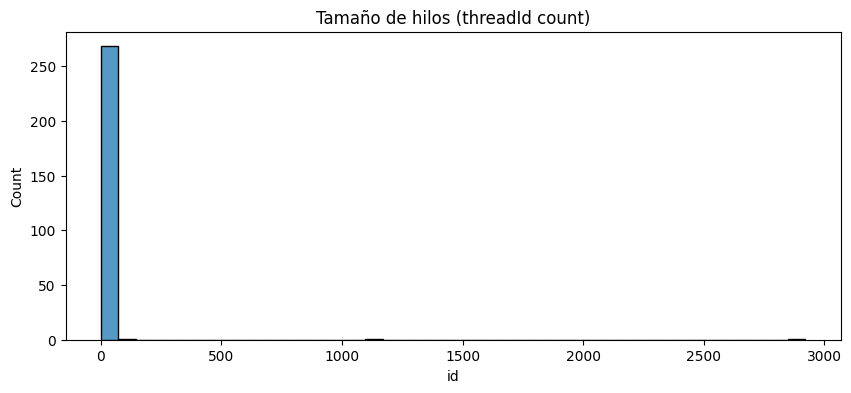

In [17]:
plt.figure(figsize=(10,4))
sns.histplot(tam_hilos, bins=40)
plt.title("Tamaño de hilos (threadId count)")
plt.show()


In [18]:
hilo_top = tam_hilos.index[0]
hilo_top


'tikapi_7520805329748151557'

In [19]:
df_small[df_small["threadId"] == hilo_top].sort_values("createdAt")[["id","parentId","createdAt","text"]].head(20)


,id,parentId,createdAt,text
930,tikapi_7520805329748151557,,NaT,🚨EL GUERRILLERO PETRO <q>ELIMIN&Oacute;</q> LO...
933,tikapi_7520805329748151557_7520806303167791879,tikapi_7520805329748151557,NaT,😱😱😱😱😱😱😱😱😱
934,tikapi_7520805329748151557_7520806841208587016,tikapi_7520805329748151557,NaT,😂😂😂😂 yo tambi&eacute;n me encanta tu contenido...
935,tikapi_7520805329748151557_7520806857570222869,tikapi_7520805329748151557,NaT,Cositas 😂😂😂😂😂
936,tikapi_7520805329748151557_7520806971516994312,tikapi_7520805329748151557,NaT,🤣🤣🤣 Dios
937,tikapi_7520805329748151557_7520807104653001493,tikapi_7520805329748151557,NaT,jajaja Jajaja hay petristas
939,tikapi_7520805329748151557_7520806420041220872,tikapi_7520805329748151557,NaT,Es genial su contenido 😂😂😂😂😂😂
940,tikapi_7520805329748151557_7520807291303035666,tikapi_7520805329748151557,NaT,😃😃😃😃😃😃😃😂
941,tikapi_7520805329748151557_7520807345313022728,tikapi_7520805329748151557,NaT,🤷&zwj;♂️. Y acaso los petristas trabajan?
942,tikapi_7520805329748151557_7520807424098648839,tikapi_7520805329748151557,NaT,"Que m&aacute;s se puede esperar de un asesino,..."


Podemos ver que todos los comentarios referencias directamente al root, es decir, la mayoría de comentarios responden al video original, no entre ellos.